In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import random
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from optbinning import OptimalBinning

from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import scale, robust_scale, power_transform

from src import *

set_seeds()
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
train_raw = pd.read_csv('../data/raw/cs-training.csv').drop(columns=['Unnamed: 0'])
print(f"Data shape: {train_raw.shape}")

X_train = train_raw.drop(columns=['SeriousDlqin2yrs']).copy()
y_train = train_raw['SeriousDlqin2yrs'].copy()

Data shape: (150000, 11)


In [3]:
config = get_config()

pipeline = create_preprocessing_pipeline(config)

pipeline.fit(X_train, y_train)
X_train_processed = pd.DataFrame(pipeline.transform(X_train), columns=pipeline[-1].get_feature_names_out())

In [4]:
X_train_processed.describe()

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,age^2,age^3,DebtRatio^2,DebtRatio^3,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,total_delinquencies,has_delinquency,weighted_delinquencies
count,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05
mean,-1.466560e-16,1.234450e-16,8.981260e-17,1.441928e-16,1.515825e-17,1.515825e-17,-4.357995e-17,-1.061077e-17,-1.042129e-18,6.821210e-18,4.054831e-17,-1.117921e-17,-3.789561e-18,-5.153803e-17,4.736952e-19,2.766380e-17,-3.221127e-18,-1.231607e-17,1.477929e-17,7.863340e-17,5.456968e-17,1.946887e-17,-6.044350e-17,-8.337035e-17,-7.958079e-18,-6.186459e-17,-2.486900e-17,2.539006e-17,-2.178998e-18,8.905469e-18,4.320100e-17,-5.153803e-17,2.842171e-18,-5.684342e-19
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.127567e+00,-1.270292e+00,-9.133445e-01,-1.237607e+00,-6.802357e-01,-1.699019e+00,-1.006900e+00,-3.687091e-01,-2.177823e-01,-2.153169e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,-6.893383e-01,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.575598e+00,-1.200172e+00,-5.000670e-01,-2.582308e-01,-8.710791e-01,-5.655466e-01,-6.344194e-01,-4.278152e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
25%,-7.666002e-01,-8.547205e-01,-8.278820e-01,-5.758495e-01,-6.802357e-01,-6.881796e-01,-1.006900e+00,-3.687091e-01,-2.177823e-01,-2.153169e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,-6.893383e-01,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-7.961715e-01,-7.736520e-01,-4.135665e-01,-2.485012e-01,-6.420741e-01,-5.117043e-01,-6.344194e-01,-4.278152e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
50%,-1.806820e-02,-1.019999e-01,-4.721729e-01,-1.614391e-01,-6.802357e-01,-8.167584e-02,7.506605e-03,-3.687091e-01,-2.177823e-01,-2.153169e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,-6.893383e-01,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.531448e-01,-2.611490e-01,-2.713066e-01,-2.163861e-01,-2.848264e-01,-3.450086e-01,-3.102487e-01,-3.372201e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
75%,7.304638e-01,7.137267e-01,6.863061e-01,2.959207e-01,2.539744e-01,5.248279e-01,1.021913e+00,-3.687091e-01,-2.177823e-01,-2.153169e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,1.450666e+00,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,1.233687e+00,-5.108630e-01,-1.679079e-01,-4.992290e-01,6.419956e-01,5.212497e-01,-3.554731e-02,-1.371499e-01,2.373048e-01,7.766091e-03,6.622635e-01,2.969452e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
max,2.363624e+00,1.857487e+00,1.948048e+00,6.3

In [5]:
config_woe = get_config()

config_woe.preprocessing.imputation = ImputationConfig(features_skip_imputation=['NumberOfDependents'])

config_woe.preprocessing.outlier_clipping = OutlierClippingConfig(enabled=False)

config_woe.preprocessing.feature_transformation = FeatureTransformationConfig(transformations={})
config_woe.preprocessing.woe = WoEConfig(enabled=True)

config_woe.preprocessing.scaling = ScalingConfig(enabled=False)

In [6]:
pipeline_woe = create_preprocessing_pipeline(config_woe)

pipeline_woe.fit(X_train, y_train)
X_train_woe = pd.DataFrame(pipeline_woe.transform(X_train), columns=pipeline_woe[:-2].get_feature_names_out())


Feature: age


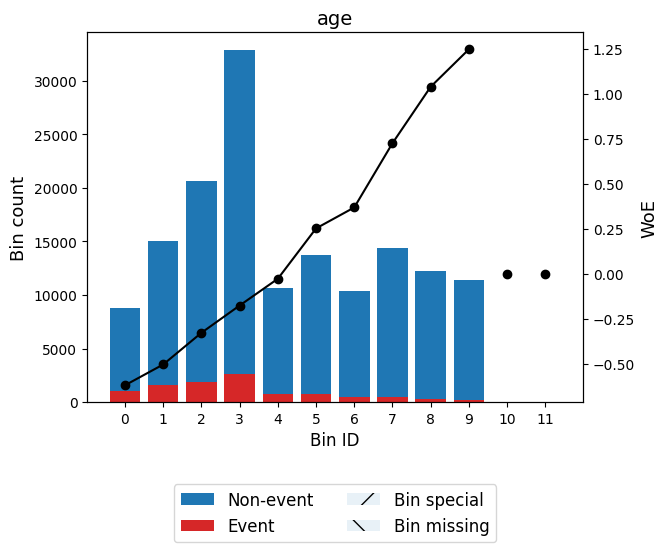


Feature: MonthlyIncome


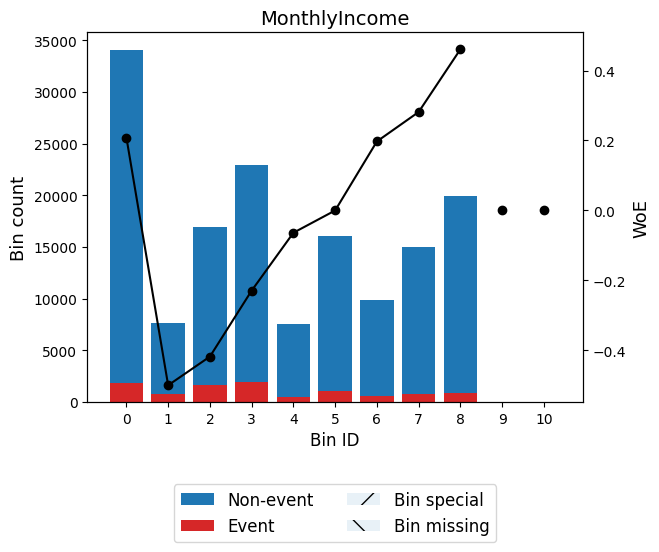


Feature: RevolvingUtilizationOfUnsecuredLines


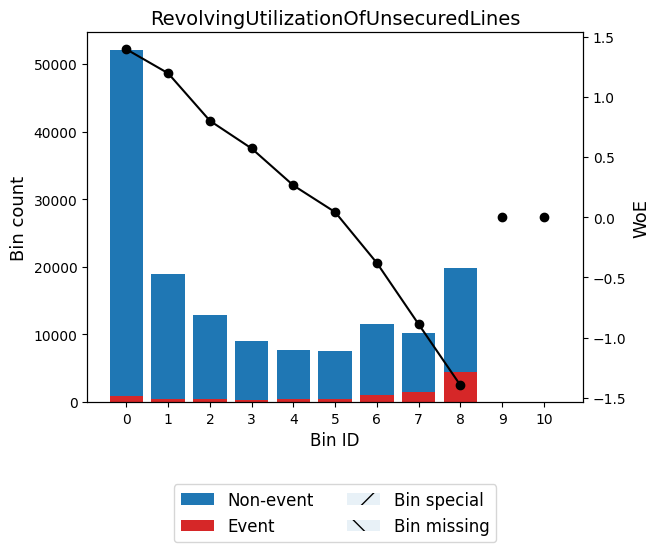


Feature: DebtRatio


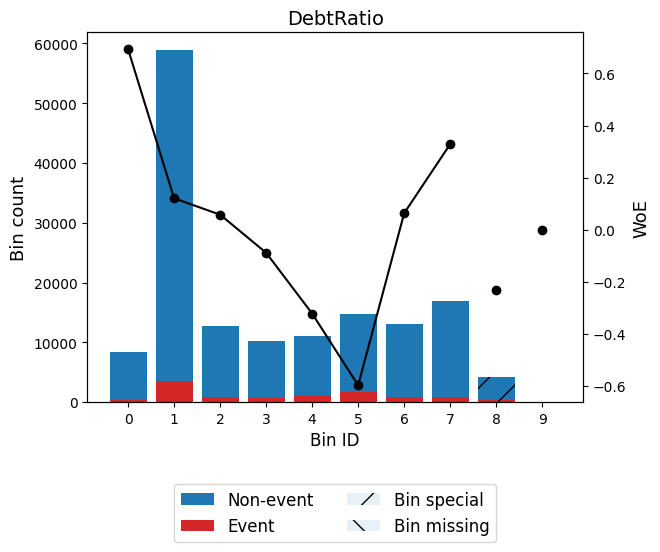


Feature: NumberOfDependents


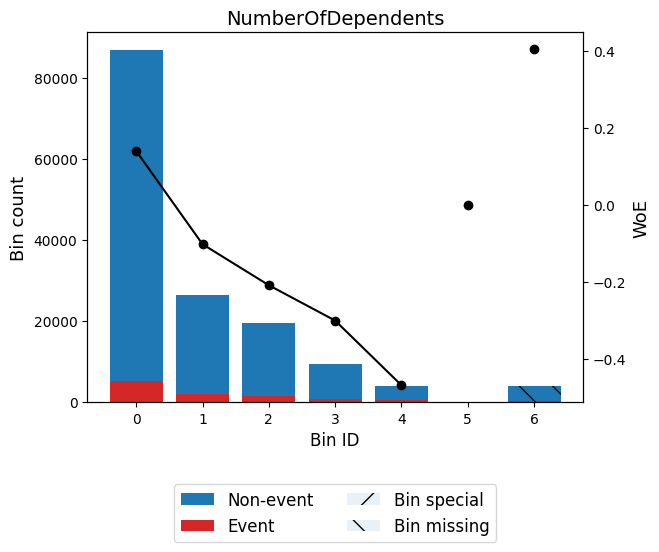


Feature: NumberOfOpenCreditLinesAndLoans


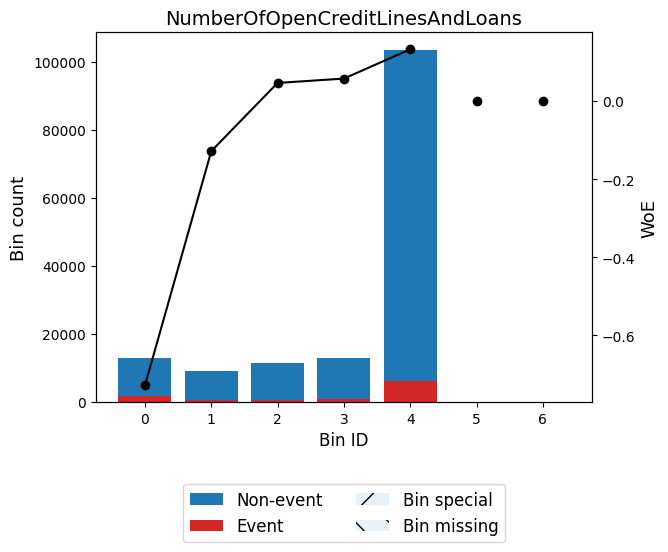


Feature: NumberRealEstateLoansOrLines


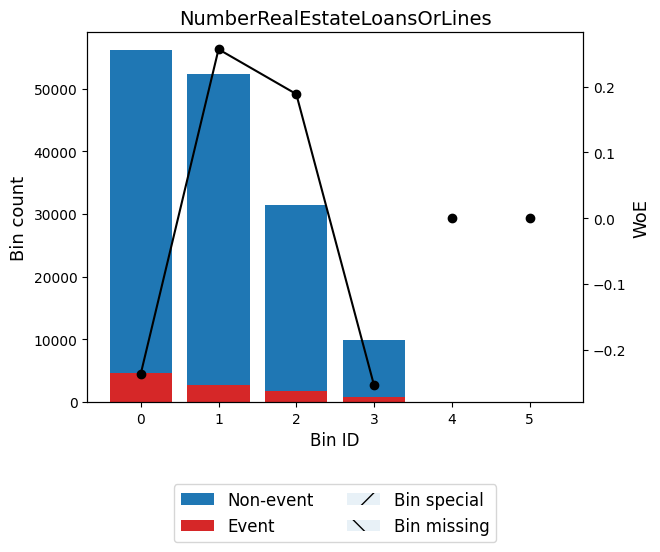


Feature: NumberOfTime30-59DaysPastDueNotWorse


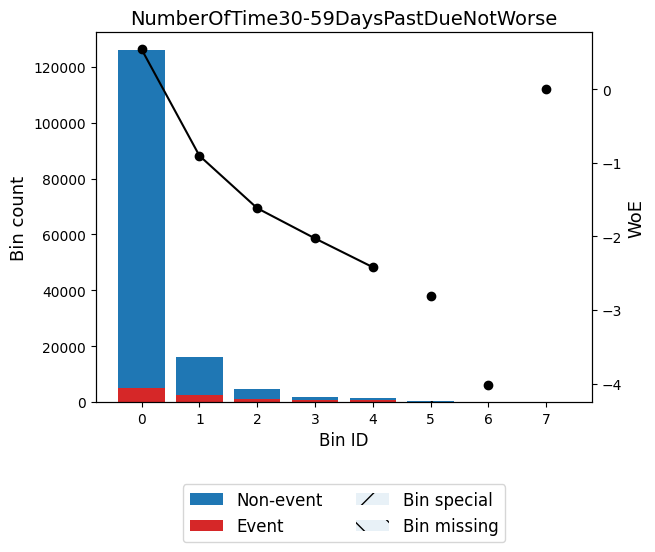


Feature: NumberOfTime60-89DaysPastDueNotWorse


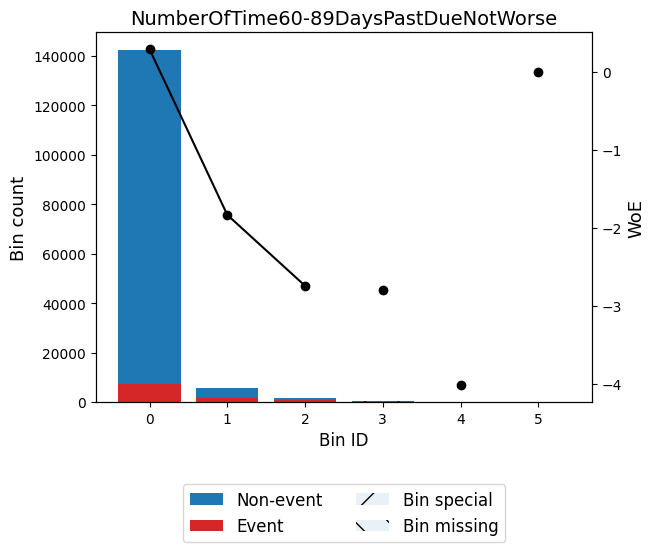


Feature: NumberOfTimes90DaysLate


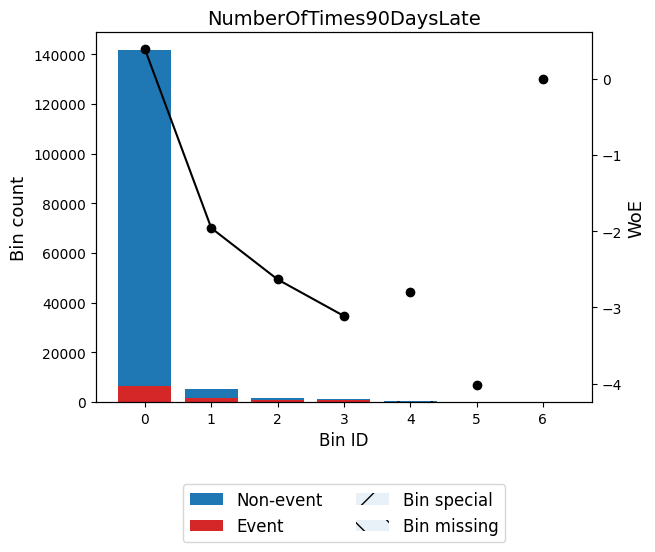

In [7]:
pipeline_woe.named_steps['transformation'].named_steps['woe'].print_summary()

In [8]:
pipeline_woe.named_steps['transformation'].named_steps['woe'].get_binning_table('DebtRatio')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.02)",8296,0.055307,8009,287,0.034595,0.692564,0.019802,0.002427
1,"[0.02, 0.35)",58882,0.392547,55367,3515,0.059696,0.120669,0.005426,0.000678
2,"[0.35, 0.42)",12807,0.085380,11996,811,0.063325,0.057786,0.000278,0.000035
3,"[0.42, 0.51)",10183,0.067887,9444,739,0.072572,-0.088438,0.000552,0.000069
4,"[0.51, 0.65)",10998,0.073320,10009,989,0.089925,-0.321729,0.008731,0.001087
5,"[0.65, 3.97)",14652,0.097680,12965,1687,0.115138,-0.596973,0.045154,0.005562
6,"[3.97, 995.50)",13144,0.087627,12316,828,0.062995,0.063366,0.000342,0.000043
7,"[995.50, inf)",16925,0.112833,16095,830,0.049040,0.328563,0.010580,0.001317
8,zero,4113,0.027420,3773,340,0.082665,-0.229595,0.001597,0.000199
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


In [9]:
X_train_woe.describe()

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,age^2,age^3,DebtRatio^2,DebtRatio^3,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,total_delinquencies,has_delinquency,weighted_delinquencies
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,1.500000e+05,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.125602,0.038669,0.480237,0.045326,0.004667,0.029220,0.023970,0.263844,0.174067,0.245961,0.198207,0.026160,0.058807,0.32212,0.079400,0.010893,0.041373,0.022140,0.068373,0.396513,0.206967,0.027420,0.199507,2952.995207,1.778590e+05,4.277289e+06,8.096944e+11,97.929787,1441.052120,2.313187,9.976400,0.927393,0.202420,1.699727
std,0.570734,0.296318,1.013906,0.293153,0.173935,0.242082,0.234544,0.666477,0.507988,0.608987,0.398650,0.159611,0.235263,0.46729,0.270363,0.103801,0.199153,0.147139,0.252386,0.489175,0.405133,0.163304,0.399631,1608.140400,1.427074e+05,4.878640e+08,1.521774e+14,129.373043,3788.085473,11.292787,438.096054,12.466204,0.401805,24.928492
min,-0.618349,-0.499983,-1.396248,-0.596973,-0.469533,-0.727837,-0.253629,-2.418551,-2.746111,-3.112420,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.326797,-0.229311,-0.380305,0.000000,-0.102578,0.057593,-0.235970,0.541721,0.288208,0.389724,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1681.000000,6.892100e+04,3.065085e-02,5.366161e-03,25.000000,125.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-0.175225,0.197259,0.801477,0.120669,0.139828,0.132641,0.188639,0.541721,0.288208,0.389724,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2704.000000,1.406080e+05,1.343280e-01,4.923226e-02,64.000000,512.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,0.726566,0.208442,1.395448,0.120669,0.139828,0.132641,0.256641,0.541721,0.288208,0.389724,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3969.000000,2.500470e+05,7.538646e-01,6.545458e-01,121.000000,1331.000000,4.000000,8.000000,0.000000,0.000000,0.000000
max,1.248390,0.460761,1.395448,0.692564,0.139828,0.132641,0.256641,0.541721,0.288208,0.389724,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11881.000000,1.295029e+06,1.086784e+11,3.582734e+16,3364.000000,195112.000000,2916.000000,157464.000000,294.000000,1.000000,588.000000
